# Diagnóstico de desempenho a partir do padrão de ausência

Quanto do desempenho publicado no teste de 2024, AUPRC em torno de 0,63, é reproduzível apenas com o padrão de preenchimento dos blocos `ALRM_*` e `GRAV_*`, sem nenhum conteúdo clínico.
A análise usa a coorte de `data/raw/dengue_hospitalized.parquet` com a partição temporal do estudo, treino de 2020 a 2023 e teste de 2024, e reserva 2025 para a avaliação de estabilidade.
Produz as métricas de cinco braços construídos somente com indicadores de ausência, a leitura do braço de blocos como regra determinística sem modelo, e o contraste com o conteúdo clínico no subconjunto em que o bloco de gravidade foi preenchido.
Diagnóstico descritivo: nenhum modelo de referência é retreinado, nada é escrito em `output/`, e nenhum arquivo do pipeline é modificado.

## Etapas
1. Construir os 24 indicadores de ausência a partir do código bruto do SINAN, antes de `treat_data.treat`.
2. Medir a completude dos indicadores por desfecho, campo a campo.
3. Montar a partição temporal do estudo e definir os cinco braços de preditores.
4. Definir as métricas e o bootstrap de 2.000 reamostragens que sustenta os intervalos de confiança.
5. Treinar e avaliar os braços A a E no teste de 2024.
6. Avaliar o braço D como regra determinística, sem treino e sem probabilidade.
7. Comparar os braços com o desempenho publicado e com o piso de prevalência.
8. Extrair os coeficientes do braço A na Logistic Regression.
9. Reavaliar os braços A e D em 2025, sem retreinar.
10. Contrastar com o conteúdo clínico no subconjunto de bloco de gravidade preenchido.

## Entradas
- `data/raw/dengue_hospitalized.parquet`
- `data/features/baseline/config.json`
- `output/metricas/` (leitura apenas, para registrar os valores dos artefatos ao lado dos publicados)

## Saídas
- `analysis/results_diagnostico_ausencia/completude_indicadores_por_desfecho.csv`
- `analysis/results_diagnostico_ausencia/metricas_bracos_teste_2024.csv`
- `analysis/results_diagnostico_ausencia/matriz_confusao_bracos.csv`
- `analysis/results_diagnostico_ausencia/regra_deterministica_blocos.csv`
- `analysis/results_diagnostico_ausencia/comparativo_com_publicado.csv`
- `analysis/results_diagnostico_ausencia/coeficientes_braco_a_lr.csv`
- `analysis/results_diagnostico_ausencia/estabilidade_2024_2025.csv`
- `analysis/results_diagnostico_ausencia/contraste_clinico_grav.csv`
- `analysis/plots/diagnostico_ausencia/auprc_por_braco.png`
- `analysis/plots/diagnostico_ausencia/curvas_pr_bracos.png`
- `analysis/plots/diagnostico_ausencia/coeficientes_braco_a.png`
- `analysis/plots/diagnostico_ausencia/estabilidade_2024_2025.png`

Importações, caminhos, formatadores em português e as constantes dos dois blocos de campos clínicos.

In [1]:
import os
import sys
import json
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, precision_recall_curve
from lightgbm import LGBMClassifier

# Raiz do repositorio por marcador estavel, e nao por contagem de niveis:
# reorganizar as pastas de notebooks deixa de quebrar os caminhos.
def _raiz_repo(inicio=None):
    d = os.path.abspath(inicio or os.getcwd())
    while not any(os.path.exists(os.path.join(d, m)) for m in ('pyproject.toml', '.git')):
        pai = os.path.dirname(d)
        if pai == d:
            raise RuntimeError(f'raiz do repositorio nao encontrada acima de {os.getcwd()}')
        d = pai
    return d

ROOT = _raiz_repo()
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from utils import clean_data, treat_data, split_data

RAW_PATH = os.path.join(ROOT, 'data', 'raw', 'dengue_hospitalized.parquet')
CFG_PATH = os.path.join(ROOT, 'data', 'features', 'baseline', 'config.json')
MET_DIR  = os.path.join(ROOT, 'output', 'metricas')          # leitura apenas
OUT_TAB  = os.path.join(ROOT, 'analysis', 'results_diagnostico_ausencia')
OUT_PLT  = os.path.join(ROOT, 'analysis', 'plots', 'diagnostico_ausencia')
os.makedirs(OUT_TAB, exist_ok=True)
os.makedirs(OUT_PLT, exist_ok=True)

RANDOM_STATE = 42
N_BOOTSTRAP  = 2000
LIMIAR       = 0.5

# Estilo alinhado a notebooks/02_evaluation
COR_LR    = '#4C72B0'
COR_LGBM  = '#DD8452'
COR_REF   = '#C44E52'
COR_PISO  = '#8172B3'
DPI = 300
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': DPI, 'font.size': 9})


def salvar_fig(fig, nome):
    caminho = os.path.join(OUT_PLT, nome)
    fig.savefig(caminho, dpi=DPI, bbox_inches='tight')
    print(f'[figura] {os.path.relpath(caminho, ROOT)}')


def salvar_tab(df, nome, index=False):
    caminho = os.path.join(OUT_TAB, nome)
    df.to_csv(caminho, index=index, encoding='utf-8')
    print(f'[tabela] {os.path.relpath(caminho, ROOT)}  ({len(df)} linhas)')
    return df


ALRM_COLS = [c for c in clean_data.FEATURES if c.startswith('ALRM_')]
GRAV_COLS = [c for c in clean_data.FEATURES if c.startswith('GRAV_')]
print(f'Sinais de alarme  ({len(ALRM_COLS)}): {ALRM_COLS}')
print(f'Critérios de gravidade ({len(GRAV_COLS)}): {GRAV_COLS}')

Sinais de alarme  (9): ['ALRM_HIPOT', 'ALRM_PLAQ', 'ALRM_VOM', 'ALRM_SANG', 'ALRM_HEMAT', 'ALRM_ABDOM', 'ALRM_LETAR', 'ALRM_HEPAT', 'ALRM_LIQ']
Critérios de gravidade (15): ['GRAV_PULSO', 'GRAV_CONV', 'GRAV_ENCH', 'GRAV_INSUF', 'GRAV_TAQUI', 'GRAV_EXTRE', 'GRAV_HIPOT', 'GRAV_HEMAT', 'GRAV_MELEN', 'GRAV_METRO', 'GRAV_SANG', 'GRAV_AST', 'GRAV_MIOC', 'GRAV_CONSC', 'GRAV_ORGAO']


## 1. Construção dos indicadores a partir da base não tratada

A fusão de ausente com "não" não ocorre em `utils/treat_data.py`: `remap_binary_sinan` mapeia `1` para 1, `2` para 0 e `9`, branco ou qualquer outro código para `NaN`.
A conversão de ausente em 0 acontece um passo adiante, no `ColumnTransformer` de cada notebook de modelo em `notebooks/01_models`, com `SimpleImputer(strategy='constant', fill_value=0)` sobre `ALRM_COLS + GRAV_COLS`.
A consequência é que os modelos publicados receberam esses 24 campos como binários em que 0 significa "ausente ou negativo", sem distinção, e o valor 1 carrega por construção a informação de que o bloco foi preenchido.

`aus_<CAMPO> = 1` quando o código bruto do SINAN não é `1` nem `2`, isto é, exatamente o conjunto que `remap_binary_sinan` converteria em `NaN` e que o `ColumnTransformer` converte em 0.
Os indicadores são derivados de `data/raw/dengue_hospitalized.parquet` porque ali o código bruto é inequívoco, e só depois a base passa por `treat_data.treat` para obter `target` e `year`: inverter a ordem apagaria a informação a ser medida.

In [2]:
bruto = pd.read_parquet(RAW_PATH, engine='pyarrow')
print(f'{os.path.relpath(RAW_PATH, ROOT)}: {len(bruto):,} registros | {bruto.shape[1]} colunas')

# ── indicadores de ausencia, sobre o codigo bruto ─────────────────────────────
indicadores = {}
for c in ALRM_COLS + GRAV_COLS:
    codigo = pd.to_numeric(bruto[c].astype(str).str.strip(), errors='coerce')
    indicadores[f'aus_{c}'] = (~codigo.isin([1, 2])).astype('int8')

indicadores = pd.DataFrame(indicadores, index=bruto.index)
AUS_COLS      = list(indicadores.columns)
AUS_ALRM_COLS = [f'aus_{c}' for c in ALRM_COLS]
AUS_GRAV_COLS = [f'aus_{c}' for c in GRAV_COLS]

# ── so agora o tratamento do pipeline ─────────────────────────────────────────
tratado = treat_data.treat(bruto.copy())

dados = pd.concat([indicadores, tratado[['target', 'year'] + ALRM_COLS + GRAV_COLS]], axis=1)

# blocos: preenchido = pelo menos um campo do bloco com codigo valido
dados['bloco_alrm_preenchido'] = (indicadores[AUS_ALRM_COLS].sum(axis=1) < len(ALRM_COLS)).astype('int8')
dados['bloco_grav_preenchido'] = (indicadores[AUS_GRAV_COLS].sum(axis=1) < len(GRAV_COLS)).astype('int8')

print(f'\nCoorte: {len(dados):,} registros — confere com a análise de temporalidade '
      f'(350.850)? {len(dados) == 350_850}')
print(f'Óbitos: {int(dados["target"].sum()):,} ({dados["target"].mean() * 100:.2f}%)')
print(f'Indicadores construídos: {len(AUS_COLS)} '
      f'({len(AUS_ALRM_COLS)} de alarme + {len(AUS_GRAV_COLS)} de gravidade)')
print('Origem: data/raw/dengue_hospitalized.parquet, ANTES de treat_data.treat — confirmado.')

# prova de que a ordem importa: nos dados tratados o ausente ainda e NaN, mas depois
# do ColumnTransformer dos notebooks de modelo ele seria indistinguivel do valor 0
exemplo = GRAV_COLS[0]
print(f'\nProva da equivalência, em {exemplo}:')
print(f'  ausente no código bruto (aus_{exemplo} == 1): {int(indicadores[f"aus_{exemplo}"].sum()):,}')
print(f'  NaN em dengue_treated após treat():           {int(tratado[exemplo].isna().sum()):,}')
print(f'  iguais? {int(indicadores[f"aus_{exemplo}"].sum()) == int(tratado[exemplo].isna().sum())}')

data/raw/dengue_hospitalized.parquet: 350,850 registros | 62 colunas



Coorte: 350,850 registros — confere com a análise de temporalidade (350.850)? True
Óbitos: 9,451 (2.69%)
Indicadores construídos: 24 (9 de alarme + 15 de gravidade)
Origem: data/raw/dengue_hospitalized.parquet, ANTES de treat_data.treat — confirmado.

Prova da equivalência, em GRAV_PULSO:
  ausente no código bruto (aus_GRAV_PULSO == 1): 338,367
  NaN em dengue_treated após treat():           338,367
  iguais? True


Completude dos indicadores por desfecho, campo a campo, com a razão entre a ausência nos óbitos e nas curas: se o preenchimento ocorresse apenas na notificação, a completude não dependeria de um desfecho ainda não ocorrido.

In [3]:
# Completude dos indicadores por desfecho — reproduz a Etapa 2.6 da analise de temporalidade
n_obito_coorte = int(dados['target'].sum())
n_cura_coorte  = int((dados['target'] == 0).sum())

linhas = []
for c in ALRM_COLS + GRAV_COLS:
    a = dados[f'aus_{c}']
    linhas.append({
        'campo': c,
        'bloco': 'alarme' if c.startswith('ALRM_') else 'gravidade',
        'pct_ausente_coorte': round(a.mean() * 100, 2),
        'pct_ausente_obito': round(a[dados['target'] == 1].mean() * 100, 2),
        'pct_ausente_cura': round(a[dados['target'] == 0].mean() * 100, 2),
        'n_base_obito': n_obito_coorte,
        'n_base_cura': n_cura_coorte,
    })

completude = pd.DataFrame(linhas)
completude['razao_ausencia_obito_cura'] = (
    completude['pct_ausente_obito'] / completude['pct_ausente_cura']).round(3)

salvar_tab(completude, 'completude_indicadores_por_desfecho.csv')
display(completude)

for bloco in ['alarme', 'gravidade']:
    b = completude[completude['bloco'] == bloco]
    print(f'{bloco:>10}: ausência média {b["pct_ausente_cura"].mean():.1f}% nas curas '
          f'contra {b["pct_ausente_obito"].mean():.1f}% nos óbitos')

[tabela] analysis/results_diagnostico_ausencia/completude_indicadores_por_desfecho.csv  (24 linhas)


,campo,bloco,pct_ausente_coorte,pct_ausente_obito,pct_ausente_cura,n_base_obito,n_base_cura,razao_ausencia_obito_cura
0,ALRM_HIPOT,alarme,69.24,25.09,70.46,9451,341399,0.356
1,ALRM_PLAQ,alarme,69.16,24.84,70.38,9451,341399,0.353
2,ALRM_VOM,alarme,69.25,25.21,70.47,9451,341399,0.358
3,ALRM_SANG,alarme,69.23,25.11,70.46,9451,341399,0.356
4,ALRM_HEMAT,alarme,69.29,25.50,70.51,9451,341399,0.362
5,ALRM_ABDOM,alarme,69.21,25.01,70.43,9451,341399,0.355
6,ALRM_LETAR,alarme,69.27,25.34,70.49,9451,341399,0.359
7,ALRM_HEPAT,alarme,69.32,25.66,70.53,9451,341399,0.364
8,ALRM_LIQ,alarme,69.30,25.64,70.51,9451,341399,0.364
9,GRAV_PULSO,gravidade,96.44,34.93,98.14,9451,341399,0.356


    alarme: ausência média 70.5% nas curas contra 25.3% nos óbitos
 gravidade: ausência média 98.2% nas curas contra 35.0% nos óbitos


## 2. Partição temporal e definição dos braços

Mesma partição do estudo, importada de `utils/split_data.py`: treino `year in [2020, 2021,
2022, 2023]`, teste `year == 2024`. 2025 fica reservado para a análise de estabilidade.
`year` vem de `SEM_PRI // 100` (`treat_data.py:86`), como no pipeline.

In [4]:
with open(CFG_PATH) as f:
    cfg = json.load(f)

m_treino = dados['year'].isin(split_data.TRAIN_YEARS)
m_teste  = dados['year'].isin(split_data.TEST_YEARS)
m_2025   = dados['year'] == 2025

treino = dados[m_treino].copy()
teste  = dados[m_teste].copy()
val25  = dados[m_2025].copy()

y_treino = treino['target'].to_numpy()
y_teste  = teste['target'].to_numpy()

N_TESTE      = len(teste)
EVENTOS_TESTE = int(y_teste.sum())
PREVALENCIA  = y_teste.mean()

print(f'Treino {split_data.TRAIN_YEARS}: {len(treino):,} registros | {int(y_treino.sum()):,} óbitos '
      f'({y_treino.mean() * 100:.2f}%)')
print(f'Teste  {split_data.TEST_YEARS}: {N_TESTE:,} registros | {EVENTOS_TESTE:,} óbitos '
      f'({PREVALENCIA * 100:.2f}%)')
print(f'2025 (estabilidade): {len(val25):,} registros | {int(val25["target"].sum()):,} óbitos '
      f'({val25["target"].mean() * 100:.2f}%)')
print()
print(f'config.json do pipeline: train_size={cfg["train_size"]:,} train_events={cfg["train_events"]:,} '
      f'| test_size={cfg["test_size"]:,} test_events={cfg["test_events"]:,}')
print(f'Confere? {len(treino) == cfg["train_size"] and int(y_treino.sum()) == cfg["train_events"] and N_TESTE == cfg["test_size"] and EVENTOS_TESTE == cfg["test_events"]}')

BRACOS = {
    'A. Ausência total (24)':   AUS_COLS,
    'B. Ausência ALRM (9)':     AUS_ALRM_COLS,
    'C. Ausência GRAV (15)':    AUS_GRAV_COLS,
    'D. Bloco preenchido (2)':  ['bloco_alrm_preenchido', 'bloco_grav_preenchido'],
    'E. Um indicador (1)':      ['bloco_grav_preenchido'],
}
# E e um baseline extremo: so LR, como especificado
ALGOS_POR_BRACO = {nome: (['LR'] if nome.startswith('E.') else ['LR', 'LightGBM'])
                   for nome in BRACOS}

print()
for nome, cols in BRACOS.items():
    print(f'{nome:26s} {len(cols):>2} preditor(es)  algoritmos: {", ".join(ALGOS_POR_BRACO[nome])}')

Treino [2020, 2021, 2022, 2023]: 127,074 registros | 2,624 óbitos (2.06%)
Teste  [2024]: 160,302 registros | 5,292 óbitos (3.30%)
2025 (estabilidade): 63,066 registros | 1,530 óbitos (2.43%)

config.json do pipeline: train_size=127,074 train_events=2,624 | test_size=160,302 test_events=5,292
Confere? True

A. Ausência total (24)     24 preditor(es)  algoritmos: LR, LightGBM
B. Ausência ALRM (9)        9 preditor(es)  algoritmos: LR, LightGBM
C. Ausência GRAV (15)      15 preditor(es)  algoritmos: LR, LightGBM
D. Bloco preenchido (2)     2 preditor(es)  algoritmos: LR, LightGBM
E. Um indicador (1)         1 preditor(es)  algoritmos: LR


## 3. Métricas e intervalos de confiança

As mesmas métricas da análise de referência, no limiar de 0,5. IC 95% por bootstrap não paramétrico de 2.000
reamostragens com reposição sobre o conjunto de teste, `random_state=42`, método percentil.

Duas notas de implementação:

- `ap_auc` calcula AUPRC e ROC-AUC num único `argsort`. A verificação abaixo compara com
  `average_precision_score` e `roc_auc_score` do scikit-learn nos próprios dados e reporta a
  diferença absoluta, que fica na ordem de 1e-9 (acúmulo em ponto flutuante, não divergência de
  definição). Sem isso, 2.000 reamostragens sobre 160.302 registros × 11 modelos ficariam caras
  o bastante para desencorajar rodar o notebook inteiro.
- As reamostragens são idênticas entre braços — o gerador é reinicializado com a mesma
  semente para cada modelo. Os ICs são, portanto, diretamente comparáveis entre si.

In [5]:
def ap_auc(y, p):
    '''AUPRC e ROC-AUC num unico argsort; empates tratados como no scikit-learn.'''
    ordem = np.argsort(-p, kind='mergesort')
    ys, ps = y[ordem], p[ordem]
    tp = np.cumsum(ys)
    fp = np.cumsum(1.0 - ys)
    n_pos, n_neg = tp[-1], fp[-1]
    if n_pos == 0 or n_neg == 0:
        return np.nan, np.nan
    fim = np.r_[np.flatnonzero(np.diff(ps) != 0), len(ps) - 1]
    tp_f, fp_f = tp[fim], fp[fim]
    prec = tp_f / (tp_f + fp_f)
    rec = tp_f / n_pos
    auprc = float(np.sum(np.diff(np.r_[0.0, rec]) * prec))
    tpr = np.r_[0.0, tp_f / n_pos]
    fpr = np.r_[0.0, fp_f / n_neg]
    return auprc, float(np.trapezoid(tpr, fpr))


# verificacao contra o scikit-learn, nos proprios dados
from sklearn.metrics import average_precision_score as _ap, roc_auc_score as _auc
_rng = np.random.RandomState(0)
_p = _rng.rand(len(y_teste))
_a, _b = ap_auc(y_teste, _p)
_a_sk, _b_sk = _ap(y_teste, _p), _auc(y_teste, _p)
print(f'Verificação de ap_auc contra o scikit-learn, sobre y_teste com scores aleatórios:')
print(f'  AUPRC   {_a:.12f} vs {_a_sk:.12f}  | diferença {abs(_a - _a_sk):.3e}')
print(f'  ROC-AUC {_b:.12f} vs {_b_sk:.12f}  | diferença {abs(_b - _b_sk):.3e}')
assert abs(_a - _a_sk) < 1e-8 and abs(_b - _b_sk) < 1e-8, 'ap_auc divergiu do scikit-learn'


def metricas_ponto(y, p, limiar=LIMIAR):
    pred = (p >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    auprc, roc = ap_auc(y, p)
    return {
        'auprc': auprc,
        'roc_auc': roc,
        'sensibilidade': tp / (tp + fn) if (tp + fn) else np.nan,
        'especificidade': tn / (tn + fp) if (tn + fp) else np.nan,
        'vpp': tp / (tp + fp) if (tp + fp) else np.nan,
        'vpn': tn / (tn + fn) if (tn + fn) else np.nan,
        'vp': int(tp), 'vn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }


def ic_bootstrap(y, p, limiar=LIMIAR, n=N_BOOTSTRAP, semente=RANDOM_STATE):
    '''IC 95% percentil para AUPRC, ROC-AUC e sensibilidade.'''
    rng = np.random.RandomState(semente)
    n_obs = len(y)
    acc = {'auprc': [], 'roc_auc': [], 'sensibilidade': []}
    pred = (p >= limiar).astype(int)
    for _ in range(n):
        i = rng.randint(0, n_obs, n_obs)
        yb, pb = y[i], p[i]
        if yb.sum() == 0 or yb.sum() == n_obs:
            continue
        a, r = ap_auc(yb, pb)
        acc['auprc'].append(a)
        acc['roc_auc'].append(r)
        pb_pred = pred[i]
        acc['sensibilidade'].append(pb_pred[yb == 1].mean())
    return {k: (float(np.percentile(v, 2.5)), float(np.percentile(v, 97.5)))
            for k, v in acc.items()}


def construir_modelo(algo):
    '''Hiperparametros padrao; nenhum GridSearch. Mesma ponderacao de classes do pipeline de referencia.'''
    if algo == 'LR':
        return Pipeline([
            ('imp', SimpleImputer(strategy='constant', fill_value=0)),
            ('clf', LogisticRegression(class_weight='balanced', max_iter=1000,
                                       random_state=RANDOM_STATE, solver='lbfgs')),
        ])
    return LGBMClassifier(class_weight='balanced', random_state=RANDOM_STATE, verbose=-1)


def treinar_avaliar(cols, algo, df_treino, df_teste, rotulo, com_ic=True):
    modelo = construir_modelo(algo)
    modelo.fit(df_treino[cols], df_treino['target'])
    proba = modelo.predict_proba(df_teste[cols])[:, 1]
    y = df_teste['target'].to_numpy()

    linha = {'braco': rotulo, 'algoritmo': algo, 'n_preditores': len(cols),
             'n_treino': len(df_treino), 'eventos_treino': int(df_treino['target'].sum()),
             'n_teste': len(df_teste), 'eventos_teste': int(y.sum()),
             'prevalencia_teste': round(float(y.mean()), 5)}
    linha.update(metricas_ponto(y, proba))

    if com_ic:
        ic = ic_bootstrap(y, proba)
        for k, (lo, hi) in ic.items():
            linha[f'{k}_ic95_inf'] = lo
            linha[f'{k}_ic95_sup'] = hi
    return linha, modelo, proba


print(f'\nBootstrap: {N_BOOTSTRAP:,} reamostragens, random_state={RANDOM_STATE}, método percentil.')

Verificação de ap_auc contra o scikit-learn, sobre y_teste com scores aleatórios:
  AUPRC   0.033019818366 vs 0.033019820321  | diferença 1.956e-09
  ROC-AUC 0.501188337803 vs 0.501188336763  | diferença 1.040e-09

Bootstrap: 2,000 reamostragens, random_state=42, método percentil.


## 4. Braços A a E — teste de 2024

Todos com a mesma partição, `class_weight='balanced'`, limiar 0,5 e hiperparâmetros padrão.
Nenhum contém valor clínico: os preditores são apenas indicadores de que o campo foi ou não
preenchido.

In [6]:
resultados, modelos, probas = [], {}, {}

for nome, cols in BRACOS.items():
    for algo in ALGOS_POR_BRACO[nome]:
        linha, modelo, proba = treinar_avaliar(cols, algo, treino, teste, nome)
        resultados.append(linha)
        modelos[(nome, algo)] = modelo
        probas[(nome, algo)] = proba
        print(f'{nome:26s} {algo:9s} AUPRC={linha["auprc"]:.4f} '
              f'[{linha["auprc_ic95_inf"]:.4f}–{linha["auprc_ic95_sup"]:.4f}]  '
              f'ROC-AUC={linha["roc_auc"]:.4f}  sens={linha["sensibilidade"]:.4f}')

metricas = pd.DataFrame(resultados)

A. Ausência total (24)     LR        AUPRC=0.3424 [0.3308–0.3544]  ROC-AUC=0.8348  sens=0.6413


A. Ausência total (24)     LightGBM  AUPRC=0.3540 [0.3421–0.3668]  ROC-AUC=0.8353  sens=0.6415


B. Ausência ALRM (9)       LR        AUPRC=0.0635 [0.0614–0.0659]  ROC-AUC=0.7117  sens=0.7489


B. Ausência ALRM (9)       LightGBM  AUPRC=0.0671 [0.0644–0.0704]  ROC-AUC=0.7152  sens=0.7549


C. Ausência GRAV (15)      LR        AUPRC=0.3403 [0.3289–0.3525]  ROC-AUC=0.8096  sens=0.6412


C. Ausência GRAV (15)      LightGBM  AUPRC=0.3398 [0.3284–0.3517]  ROC-AUC=0.8099  sens=0.6410


D. Bloco preenchido (2)    LR        AUPRC=0.3398 [0.3283–0.3520]  ROC-AUC=0.8353  sens=0.6425


D. Bloco preenchido (2)    LightGBM  AUPRC=0.3498 [0.3381–0.3621]  ROC-AUC=0.8357  sens=0.6425


E. Um indicador (1)        LR        AUPRC=0.3371 [0.3255–0.3489]  ROC-AUC=0.8105  sens=0.6425


Formatação das métricas com os intervalos de confiança para leitura em tabela.

In [7]:
def fmt_ic(df_, base):
    return (df_[base].round(4).astype(str) + ' ('
            + df_[f'{base}_ic95_inf'].round(4).astype(str) + '–'
            + df_[f'{base}_ic95_sup'].round(4).astype(str) + ')')

tabela = metricas[['braco', 'algoritmo', 'n_preditores', 'n_treino', 'eventos_treino',
                   'n_teste', 'eventos_teste', 'prevalencia_teste']].copy()
tabela['auprc_ic95']         = fmt_ic(metricas, 'auprc')
tabela['roc_auc_ic95']       = fmt_ic(metricas, 'roc_auc')
tabela['sensibilidade_ic95'] = fmt_ic(metricas, 'sensibilidade')
for c in ['especificidade', 'vpp', 'vpn']:
    tabela[c] = metricas[c].round(4)

salvar_tab(metricas.round(6), 'metricas_bracos_teste_2024.csv')
display(tabela)

[tabela] analysis/results_diagnostico_ausencia/metricas_bracos_teste_2024.csv  (9 linhas)


,braco,algoritmo,n_preditores,n_treino,eventos_treino,n_teste,eventos_teste,prevalencia_teste,auprc_ic95,roc_auc_ic95,sensibilidade_ic95,especificidade,vpp,vpn
0,A. Ausência total (24),LR,24,127074,2624,160302,5292,0.03301,0.3424 (0.3308–0.3544),0.8348 (0.8281–0.8415),0.6413 (0.6289–0.6541),0.9776,0.4942,0.9876
1,A. Ausência total (24),LightGBM,24,127074,2624,160302,5292,0.03301,0.354 (0.3421–0.3668),0.8353 (0.8288–0.842),0.6415 (0.6292–0.6542),0.9781,0.5001,0.9876
2,B. Ausência ALRM (9),LR,9,127074,2624,160302,5292,0.03301,0.0635 (0.0614–0.0659),0.7117 (0.7057–0.7175),0.7489 (0.7374–0.7606),0.6721,0.0723,0.9874
3,B. Ausência ALRM (9),LightGBM,9,127074,2624,160302,5292,0.03301,0.0671 (0.0644–0.0704),0.7152 (0.7092–0.721),0.7549 (0.7434–0.7662),0.6714,0.0727,0.9877
4,C. Ausência GRAV (15),LR,15,127074,2624,160302,5292,0.03301,0.3403 (0.3289–0.3525),0.8096 (0.8033–0.8159),0.6412 (0.6287–0.6537),0.9788,0.5085,0.9876
5,C. Ausência GRAV (15),LightGBM,15,127074,2624,160302,5292,0.03301,0.3398 (0.3284–0.3517),0.8099 (0.8037–0.8163),0.641 (0.6285–0.6537),0.9790,0.5100,0.9876
6,D. Bloco preenchido (2),LR,2,127074,2624,160302,5292,0.03301,0.3398 (0.3283–0.352),0.8353 (0.8288–0.842),0.6425 (0.6299–0.6553),0.9786,0.5063,0.9877
7,D. Bloco preenchido (2),LightGBM,2,127074,2624,160302,5292,0.03301,0.3498 (0.3381–0.3621),0.8357 (0.8292–0.8424),0.6425 (0.6299–0.6553),0.9786,0.5063,0.9877
8,E. Um indicador (1),LR,1,127074,2624,160302,5292,0.03301,0.3371 (0.3255–0.3489),0.8105 (0.8044–0.817),0.6425 (0.6299–0.6553),0.9786,0.5063,0.9877


Matriz de confusão de cada braço no limiar de 0,5, em contagens absolutas, que é a forma de ler o custo de cada ponto de operação.

In [8]:
confusao = metricas[['braco', 'algoritmo', 'vp', 'fp', 'fn', 'vn',
                     'sensibilidade', 'especificidade', 'vpp', 'vpn',
                     'n_teste', 'eventos_teste']].copy()
for c in ['sensibilidade', 'especificidade', 'vpp', 'vpn']:
    confusao[c] = confusao[c].round(4)
confusao['limiar'] = LIMIAR

salvar_tab(confusao, 'matriz_confusao_bracos.csv')
display(confusao)

[tabela] analysis/results_diagnostico_ausencia/matriz_confusao_bracos.csv  (9 linhas)


,braco,algoritmo,vp,fp,fn,vn,sensibilidade,especificidade,vpp,vpn,n_teste,eventos_teste,limiar
0,A. Ausência total (24),LR,3394,3474,1898,151536,0.6413,0.9776,0.4942,0.9876,160302,5292,0.5
1,A. Ausência total (24),LightGBM,3395,3393,1897,151617,0.6415,0.9781,0.5001,0.9876,160302,5292,0.5
2,B. Ausência ALRM (9),LR,3963,50823,1329,104187,0.7489,0.6721,0.0723,0.9874,160302,5292,0.5
3,B. Ausência ALRM (9),LightGBM,3995,50937,1297,104073,0.7549,0.6714,0.0727,0.9877,160302,5292,0.5
4,C. Ausência GRAV (15),LR,3393,3279,1899,151731,0.6412,0.9788,0.5085,0.9876,160302,5292,0.5
5,C. Ausência GRAV (15),LightGBM,3392,3259,1900,151751,0.6410,0.9790,0.5100,0.9876,160302,5292,0.5
6,D. Bloco preenchido (2),LR,3400,3316,1892,151694,0.6425,0.9786,0.5063,0.9877,160302,5292,0.5
7,D. Bloco preenchido (2),LightGBM,3400,3316,1892,151694,0.6425,0.9786,0.5063,0.9877,160302,5292,0.5
8,E. Um indicador (1),LR,3400,3316,1892,151694,0.6425,0.9786,0.5063,0.9877,160302,5292,0.5


## 5. Braço D como regra determinística, sem modelo

Classificar como óbito quando o bloco de gravidade estiver preenchido, sem treino, sem coeficiente e sem probabilidade.
Isola o quanto do desempenho vem apenas da disponibilidade do bloco, num formato que dispensa qualquer modelo para ser verificado.

In [9]:
def regra_deterministica(df_, coluna, rotulo):
    y = df_['target'].to_numpy()
    pred = df_[coluna].to_numpy().astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    # IC 95% da sensibilidade e do VPP pelo mesmo bootstrap
    rng = np.random.RandomState(RANDOM_STATE)
    sens_b, vpp_b = [], []
    for _ in range(N_BOOTSTRAP):
        i = rng.randint(0, len(y), len(y))
        yb, pb = y[i], pred[i]
        if yb.sum() == 0:
            continue
        sens_b.append(pb[yb == 1].mean())
        vpp_b.append(yb[pb == 1].mean() if pb.sum() else np.nan)
    return {
        'regra': rotulo,
        'conjunto': df_.name if hasattr(df_, 'name') else '',
        'n_base': len(df_), 'eventos': int(y.sum()),
        'prevalencia': round(float(y.mean()), 5),
        'vp': int(tp), 'fp': int(fp), 'fn': int(fn), 'vn': int(tn),
        'sensibilidade': round(tp / (tp + fn), 4),
        'sensibilidade_ic95_inf': round(float(np.percentile(sens_b, 2.5)), 4),
        'sensibilidade_ic95_sup': round(float(np.percentile(sens_b, 97.5)), 4),
        'especificidade': round(tn / (tn + fp), 4),
        'vpp': round(tp / (tp + fp), 4),
        'vpp_ic95_inf': round(float(np.nanpercentile(vpp_b, 2.5)), 4),
        'vpp_ic95_sup': round(float(np.nanpercentile(vpp_b, 97.5)), 4),
        'vpn': round(tn / (tn + fn), 4),
    }

regras = pd.DataFrame([
    regra_deterministica(teste, 'bloco_grav_preenchido',
                         'óbito se bloco de gravidade preenchido'),
    regra_deterministica(teste, 'bloco_alrm_preenchido',
                         'óbito se bloco de alarme preenchido'),
])
regras['conjunto'] = 'teste 2024'

salvar_tab(regras, 'regra_deterministica_blocos.csv')
display(regras)

r0 = regras.iloc[0]
print(f'\nRegra "{r0["regra"]}" no teste de 2024 (n={r0["n_base"]:,}, {r0["eventos"]:,} óbitos):')
print(f'  sensibilidade  {r0["sensibilidade"]:.4f}  IC95% [{r0["sensibilidade_ic95_inf"]:.4f}–{r0["sensibilidade_ic95_sup"]:.4f}]')
print(f'  especificidade {r0["especificidade"]:.4f}')
print(f'  VPP            {r0["vpp"]:.4f}  IC95% [{r0["vpp_ic95_inf"]:.4f}–{r0["vpp_ic95_sup"]:.4f}]')
print(f'  VPN            {r0["vpn"]:.4f}')
print(f'  matriz: VP={r0["vp"]:,}  FP={r0["fp"]:,}  FN={r0["fn"]:,}  VN={r0["vn"]:,}')

[tabela] analysis/results_diagnostico_ausencia/regra_deterministica_blocos.csv  (2 linhas)


,regra,conjunto,n_base,eventos,prevalencia,vp,fp,fn,vn,sensibilidade,sensibilidade_ic95_inf,sensibilidade_ic95_sup,especificidade,vpp,vpp_ic95_inf,vpp_ic95_sup,vpn
0,óbito se bloco de gravidade preenchido,teste 2024,160302,5292,0.03301,3400,3316,1892,151694,0.6425,0.6299,0.6553,0.9786,0.5063,0.4941,0.519,0.9877
1,óbito se bloco de alarme preenchido,teste 2024,160302,5292,0.03301,3998,50954,1294,104056,0.7555,0.7441,0.7668,0.6713,0.0728,0.0707,0.075,0.9877



Regra "óbito se bloco de gravidade preenchido" no teste de 2024 (n=160,302, 5,292 óbitos):
  sensibilidade  0.6425  IC95% [0.6299–0.6553]
  especificidade 0.9786
  VPP            0.5063  IC95% [0.4941–0.5190]
  VPN            0.9877
  matriz: VP=3,400  FP=3,316  FN=1,892  VN=151,694


## 6. Comparação com o desempenho publicado

Linha de referência: os valores publicados da Logistic Regression otimizada, AUPRC 0,625, ROC-AUC 0,924 e sensibilidade 0,801, e do LightGBM otimizado, AUPRC 0,629, ROC-AUC 0,914 e sensibilidade 0,755.
`output/metricas/` é lido apenas para registrar os valores dos artefatos versionados ao lado dos publicados, porque há diferenças de arredondamento e uma diferença real na sensibilidade da Logistic Regression.
A prevalência de óbito no teste é o piso da AUPRC, o valor que um classificador aleatório alcança, e vai explicitada na tabela e na figura.

In [10]:
PUBLICADO = {
    'LR':       {'auprc': 0.625, 'roc_auc': 0.924, 'sensibilidade': 0.801},
    'LightGBM': {'auprc': 0.629, 'roc_auc': 0.914, 'sensibilidade': 0.755},
}
ARQUIVO_PUBLICADO = {
    'LR':       'logistic_regression_baseline_tuned.parquet',
    'LightGBM': 'lightgbm_baseline_tuned.parquet',
}

ref = []
for algo, vals in PUBLICADO.items():
    linha = {'fonte': 'artigo publicado', 'algoritmo': algo, **vals}
    caminho = os.path.join(MET_DIR, ARQUIVO_PUBLICADO[algo])
    if os.path.exists(caminho):
        art = pd.read_parquet(caminho).iloc[0]
        linha.update({'auprc_artefato': float(art['auprc']),
                      'roc_auc_artefato': float(art['roc_auc']),
                      'sensibilidade_artefato': float(art['sensibilidade'])})
    ref.append(linha)

referencia = pd.DataFrame(ref)
display(referencia)
print('Diferenças entre o publicado e output/metricas/ são de arredondamento, exceto a '
      'sensibilidade da LR tuned (0,801 publicada contra 0,808 no artefato).')

,fonte,algoritmo,auprc,roc_auc,sensibilidade,auprc_artefato,roc_auc_artefato,sensibilidade_artefato
0,artigo publicado,LR,0.625,0.924,0.801,0.6257,0.9244,0.8080
1,artigo publicado,LightGBM,0.629,0.914,0.755,0.6278,0.9115,0.7457


Diferenças entre o publicado e output/metricas/ são de arredondamento, exceto a sensibilidade da LR tuned (0,801 publicada contra 0,808 no artefato).


Tabela comparativa dos braços com os valores publicados e com o piso, incluindo a razão entre a AUPRC de cada braço e a publicada.

In [11]:
comparativo = metricas[['braco', 'algoritmo', 'n_preditores', 'auprc',
                        'auprc_ic95_inf', 'auprc_ic95_sup', 'roc_auc',
                        'roc_auc_ic95_inf', 'roc_auc_ic95_sup',
                        'sensibilidade', 'sensibilidade_ic95_inf', 'sensibilidade_ic95_sup',
                        'especificidade', 'vpp', 'vpn']].copy()

comparativo['auprc_publicada'] = comparativo['algoritmo'].map(
    lambda a: PUBLICADO.get(a, PUBLICADO['LR'])['auprc'])
comparativo['razao_auprc_braco_publicada'] = (
    comparativo['auprc'] / comparativo['auprc_publicada']).round(4)
comparativo['roc_auc_publicada'] = comparativo['algoritmo'].map(
    lambda a: PUBLICADO.get(a, PUBLICADO['LR'])['roc_auc'])
comparativo['prevalencia_teste_piso_auprc'] = round(float(PREVALENCIA), 5)
comparativo['n_teste'] = N_TESTE
comparativo['eventos_teste'] = EVENTOS_TESTE

# linhas de referencia, para a tabela ficar autocontida
linhas_ref = []
for algo, vals in PUBLICADO.items():
    linhas_ref.append({
        'braco': 'REFERÊNCIA — modelo publicado (tuned)', 'algoritmo': algo,
        'n_preditores': cfg['n_features'] - 1,   # 52 features menos `year`, que sai antes do fit
        'auprc': vals['auprc'], 'roc_auc': vals['roc_auc'],
        'sensibilidade': vals['sensibilidade'],
        'auprc_publicada': vals['auprc'], 'razao_auprc_braco_publicada': 1.0,
        'roc_auc_publicada': vals['roc_auc'],
        'prevalencia_teste_piso_auprc': round(float(PREVALENCIA), 5),
        'n_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
    })
linhas_ref.append({
    'braco': 'PISO — classificador aleatório', 'algoritmo': '—',
    'n_preditores': 0, 'auprc': round(float(PREVALENCIA), 5), 'roc_auc': 0.5,
    'auprc_publicada': PUBLICADO['LR']['auprc'],
    'razao_auprc_braco_publicada': round(float(PREVALENCIA) / PUBLICADO['LR']['auprc'], 4),
    'prevalencia_teste_piso_auprc': round(float(PREVALENCIA), 5),
    'n_teste': N_TESTE, 'eventos_teste': EVENTOS_TESTE,
})

comparativo = pd.concat([comparativo, pd.DataFrame(linhas_ref)], ignore_index=True)
salvar_tab(comparativo.round(6), 'comparativo_com_publicado.csv')

cols_show = ['braco', 'algoritmo', 'n_preditores', 'auprc', 'razao_auprc_braco_publicada',
             'roc_auc', 'sensibilidade', 'especificidade', 'vpp', 'vpn']
display(comparativo[cols_show].round(4))

[tabela] analysis/results_diagnostico_ausencia/comparativo_com_publicado.csv  (12 linhas)


,braco,algoritmo,n_preditores,auprc,razao_auprc_braco_publicada,roc_auc,sensibilidade,especificidade,vpp,vpn
0,A. Ausência total (24),LR,24,0.3424,0.5478,0.8348,0.6413,0.9776,0.4942,0.9876
1,A. Ausência total (24),LightGBM,24,0.3540,0.5629,0.8353,0.6415,0.9781,0.5001,0.9876
2,B. Ausência ALRM (9),LR,9,0.0635,0.1015,0.7117,0.7489,0.6721,0.0723,0.9874
3,B. Ausência ALRM (9),LightGBM,9,0.0671,0.1067,0.7152,0.7549,0.6714,0.0727,0.9877
4,C. Ausência GRAV (15),LR,15,0.3403,0.5445,0.8096,0.6412,0.9788,0.5085,0.9876
5,C. Ausência GRAV (15),LightGBM,15,0.3398,0.5402,0.8099,0.6410,0.9790,0.5100,0.9876
6,D. Bloco preenchido (2),LR,2,0.3398,0.5437,0.8353,0.6425,0.9786,0.5063,0.9877
7,D. Bloco preenchido (2),LightGBM,2,0.3498,0.5560,0.8357,0.6425,0.9786,0.5063,0.9877
8,E. Um indicador (1),LR,1,0.3371,0.5393,0.8105,0.6425,0.9786,0.5063,0.9877
9,REFERÊNCIA — modelo publicado (tuned),LR,51,0.6250,1.0000,0.9240,0.8010,NaN,NaN,NaN


### Figura principal — AUPRC por braço

[figura] analysis/plots/diagnostico_ausencia/auprc_por_braco.png


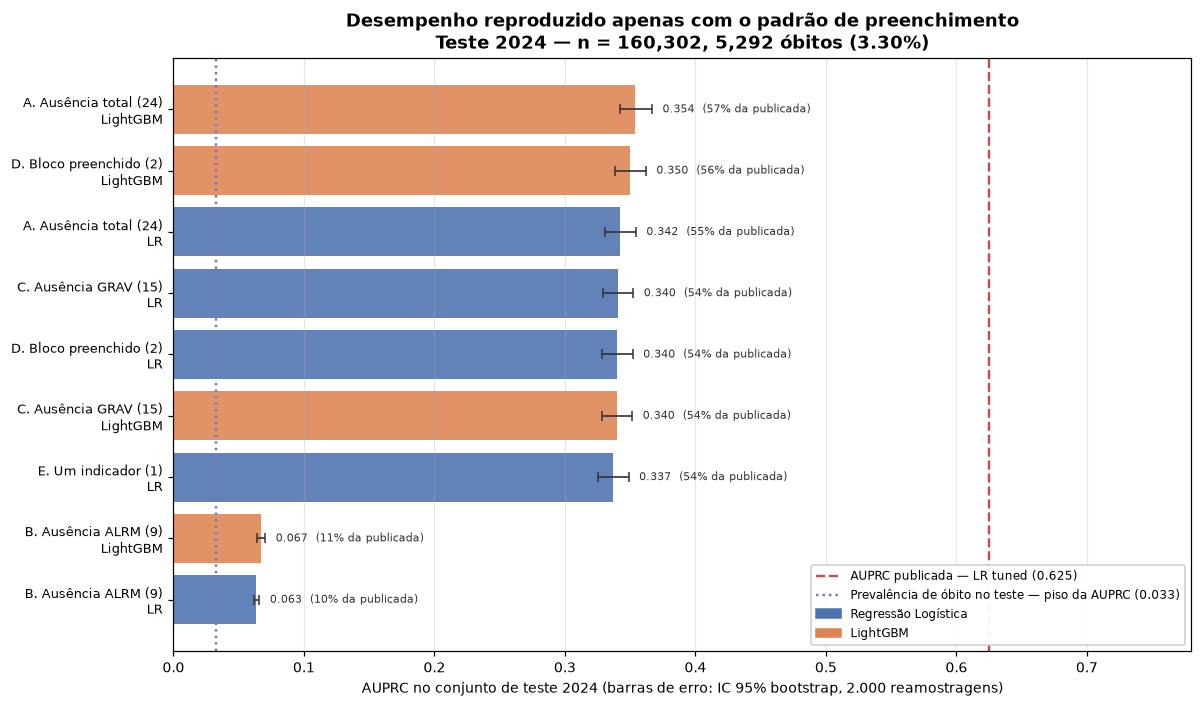

In [12]:
plot_df = metricas.copy()
plot_df['rotulo'] = plot_df['braco'] + '\n' + plot_df['algoritmo']
plot_df = plot_df.sort_values('auprc')

fig, ax = plt.subplots(figsize=(11, 6.5))
y = np.arange(len(plot_df))
cores = [COR_LR if a == 'LR' else COR_LGBM for a in plot_df['algoritmo']]
erros = np.vstack([plot_df['auprc'] - plot_df['auprc_ic95_inf'],
                   plot_df['auprc_ic95_sup'] - plot_df['auprc']])

ax.barh(y, plot_df['auprc'], color=cores, alpha=0.88,
        xerr=erros, error_kw=dict(ecolor='#333', lw=1.1, capsize=3))
ax.set_yticks(y)
ax.set_yticklabels(plot_df['rotulo'], fontsize=8.5)

ax.axvline(PUBLICADO['LR']['auprc'], color=COR_REF, ls='--', lw=1.6,
           label=f"AUPRC publicada — LR tuned ({PUBLICADO['LR']['auprc']:.3f})")
ax.axvline(PREVALENCIA, color=COR_PISO, ls=':', lw=1.6,
           label=f'Prevalência de óbito no teste — piso da AUPRC ({PREVALENCIA:.3f})')

for i, (_, r) in enumerate(plot_df.iterrows()):
    ax.text(r['auprc_ic95_sup'] + 0.008, i,
            f"{r['auprc']:.3f}  ({r['auprc'] / PUBLICADO['LR']['auprc'] * 100:.0f}% da publicada)",
            va='center', fontsize=7.5, color='#333')

from matplotlib.patches import Patch
handles, labels = ax.get_legend_handles_labels()
handles += [Patch(color=COR_LR, label='Regressão Logística'),
            Patch(color=COR_LGBM, label='LightGBM')]
ax.legend(handles=handles, fontsize=8, loc='lower right', framealpha=0.95)

ax.set_xlim(0, 0.78)
ax.set_xlabel('AUPRC no conjunto de teste 2024 (barras de erro: IC 95% bootstrap, 2.000 reamostragens)')
ax.set_title(f'Desempenho reproduzido apenas com o padrão de preenchimento\n'
             f'Teste 2024 — n = {N_TESTE:,}, {EVENTOS_TESTE:,} óbitos ({PREVALENCIA * 100:.2f}%)',
             fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
salvar_fig(fig, 'auprc_por_braco.png')
plt.show()

Curvas precisão-revocação dos braços contra o piso de prevalência, que é a referência correta sob classe rara.

[figura] analysis/plots/diagnostico_ausencia/curvas_pr_bracos.png


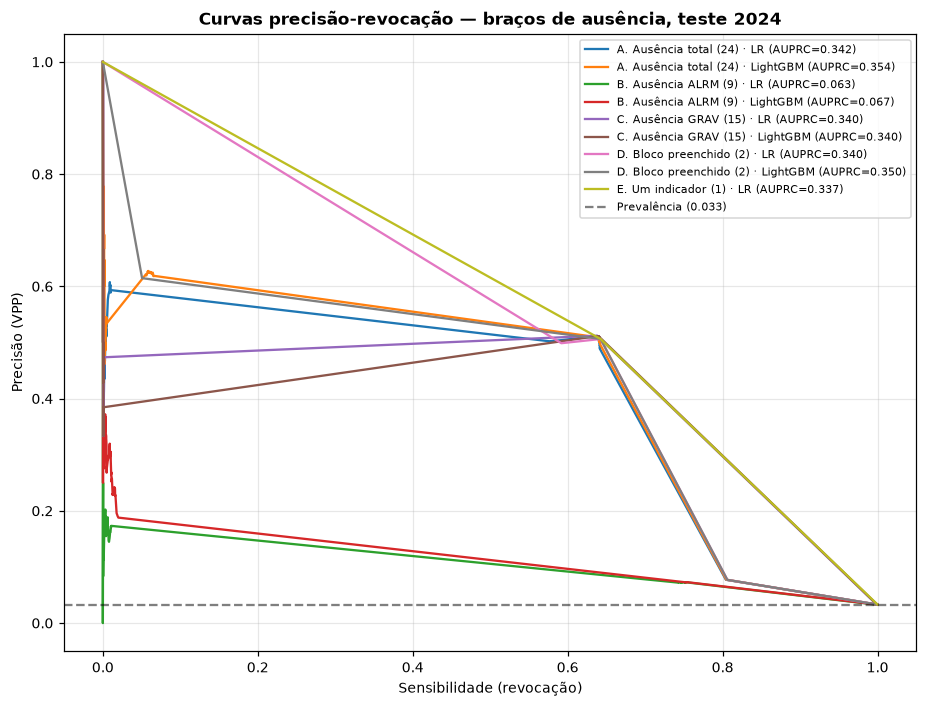

In [13]:
# Curvas precisao-revocacao dos bracos, contra o piso de prevalencia
fig, ax = plt.subplots(figsize=(8.5, 6.5))
cmap = plt.get_cmap('tab10')
for i, ((nome, algo), proba) in enumerate(probas.items()):
    prec, rec, _ = precision_recall_curve(y_teste, proba)
    ax.plot(rec, prec, lw=1.5, color=cmap(i % 10),
            label=f'{nome} · {algo} (AUPRC={ap_auc(y_teste, proba)[0]:.3f})')
ax.axhline(PREVALENCIA, color='k', ls='--', alpha=0.5,
           label=f'Prevalência ({PREVALENCIA:.3f})')
ax.set_xlabel('Sensibilidade (revocação)')
ax.set_ylabel('Precisão (VPP)')
ax.set_title('Curvas precisão-revocação — braços de ausência, teste 2024',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=7.5, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
salvar_fig(fig, 'curvas_pr_bracos.png')
plt.show()

## 7. Coeficientes do braço A (Logistic Regression)

Os 24 indicadores ordenados por |coeficiente|, com a razão de chances. Um indicador de
ausência com coeficiente negativo significa: **estar ausente reduz a chance predita de óbito**.

In [14]:
lr_a = modelos[('A. Ausência total (24)', 'LR')].named_steps['clf']
coefs = pd.DataFrame({
    'indicador': AUS_COLS,
    'campo': [c.replace('aus_', '') for c in AUS_COLS],
    'bloco': ['alarme' if 'ALRM' in c else 'gravidade' for c in AUS_COLS],
    'coeficiente': lr_a.coef_[0],
})
coefs['razao_chances_or'] = np.exp(coefs['coeficiente'])
coefs['abs_coeficiente'] = coefs['coeficiente'].abs()
coefs['sinal'] = np.where(coefs['coeficiente'] < 0, 'negativo', 'positivo')
coefs['pct_ausente_coorte'] = coefs['campo'].map(
    completude.set_index('campo')['pct_ausente_coorte'])
coefs = coefs.sort_values('abs_coeficiente', ascending=False).reset_index(drop=True)
coefs['n_treino'] = len(treino)
coefs['eventos_treino'] = int(y_treino.sum())
coefs['intercepto'] = float(lr_a.intercept_[0])

salvar_tab(coefs.round(6), 'coeficientes_braco_a_lr.csv')
display(coefs.round(4))

n_neg = int((coefs['coeficiente'] < 0).sum())
print(f'\nIndicadores com coeficiente negativo (ausência → menor risco predito): '
      f'{n_neg} de {len(coefs)}')
print(f'  |coeficiente| máximo: {coefs["abs_coeficiente"].max():.4f} '
      f'({coefs.iloc[0]["indicador"]}, OR = {coefs.iloc[0]["razao_chances_or"]:.4f})')
print(f'  |coeficiente| mínimo: {coefs["abs_coeficiente"].min():.4f} '
      f'({coefs.iloc[-1]["indicador"]}, OR = {coefs.iloc[-1]["razao_chances_or"]:.4f})')
print(f'  soma dos coeficientes: {coefs["coeficiente"].sum():.4f} | '
      f'intercepto: {lr_a.intercept_[0]:.4f}')
print('\nOs 24 indicadores são quase colineares dentro de cada bloco (a ausência é '
      'praticamente tudo-ou-nada), então coeficientes individuais se dividem entre campos '
      'do mesmo bloco e não devem ser lidos isoladamente. O sinal e a soma por bloco são '
      'o que carrega significado.')
print('\nSoma dos coeficientes por bloco:')
print(coefs.groupby('bloco')['coeficiente'].agg(['sum', 'mean', 'count']).round(4).to_string())

[tabela] analysis/results_diagnostico_ausencia/coeficientes_braco_a_lr.csv  (24 linhas)


,indicador,campo,bloco,coeficiente,razao_chances_or,abs_coeficiente,sinal,pct_ausente_coorte,n_treino,eventos_treino,intercepto
0,aus_GRAV_CONSC,GRAV_CONSC,gravidade,-2.7973,0.0610,2.7973,negativo,96.45,127074,2624,4.0036
1,aus_GRAV_SANG,GRAV_SANG,gravidade,-2.4869,0.0832,2.4869,negativo,96.46,127074,2624,4.0036
2,aus_GRAV_INSUF,GRAV_INSUF,gravidade,1.9110,6.7596,1.9110,positivo,96.45,127074,2624,4.0036
3,aus_ALRM_PLAQ,ALRM_PLAQ,alarme,-1.7109,0.1807,1.7109,negativo,69.16,127074,2624,4.0036
4,aus_ALRM_VOM,ALRM_VOM,alarme,1.5473,4.6989,1.5473,positivo,69.25,127074,2624,4.0036
5,aus_GRAV_HEMAT,GRAV_HEMAT,gravidade,1.4607,4.3089,1.4607,positivo,96.45,127074,2624,4.0036
6,aus_GRAV_EXTRE,GRAV_EXTRE,gravidade,-1.4018,0.2462,1.4018,negativo,96.45,127074,2624,4.0036
7,aus_GRAV_PULSO,GRAV_PULSO,gravidade,-1.2744,0.2796,1.2744,negativo,96.44,127074,2624,4.0036
8,aus_GRAV_METRO,GRAV_METRO,gravidade,1.2170,3.3769,1.2170,positivo,96.46,127074,2624,4.0036
9,aus_GRAV_TAQUI,GRAV_TAQUI,gravidade,-1.2142,0.2970,1.2142,negativo,96.45,127074,2624,4.0036



Indicadores com coeficiente negativo (ausência → menor risco predito): 15 de 24
  |coeficiente| máximo: 2.7973 (aus_GRAV_CONSC, OR = 0.0610)
  |coeficiente| mínimo: 0.0118 (aus_GRAV_CONV, OR = 0.9883)
  soma dos coeficientes: -5.4073 | intercepto: 4.0036

Os 24 indicadores são quase colineares dentro de cada bloco (a ausência é praticamente tudo-ou-nada), então coeficientes individuais se dividem entre campos do mesmo bloco e não devem ser lidos isoladamente. O sinal e a soma por bloco são o que carrega significado.

Soma dos coeficientes por bloco:
              sum    mean  count
bloco                           
alarme    -0.8452 -0.0939      9
gravidade -4.5621 -0.3041     15


Figura dos coeficientes do braço A, ordenados por valor, com o sinal de cada indicador.

[figura] analysis/plots/diagnostico_ausencia/coeficientes_braco_a.png


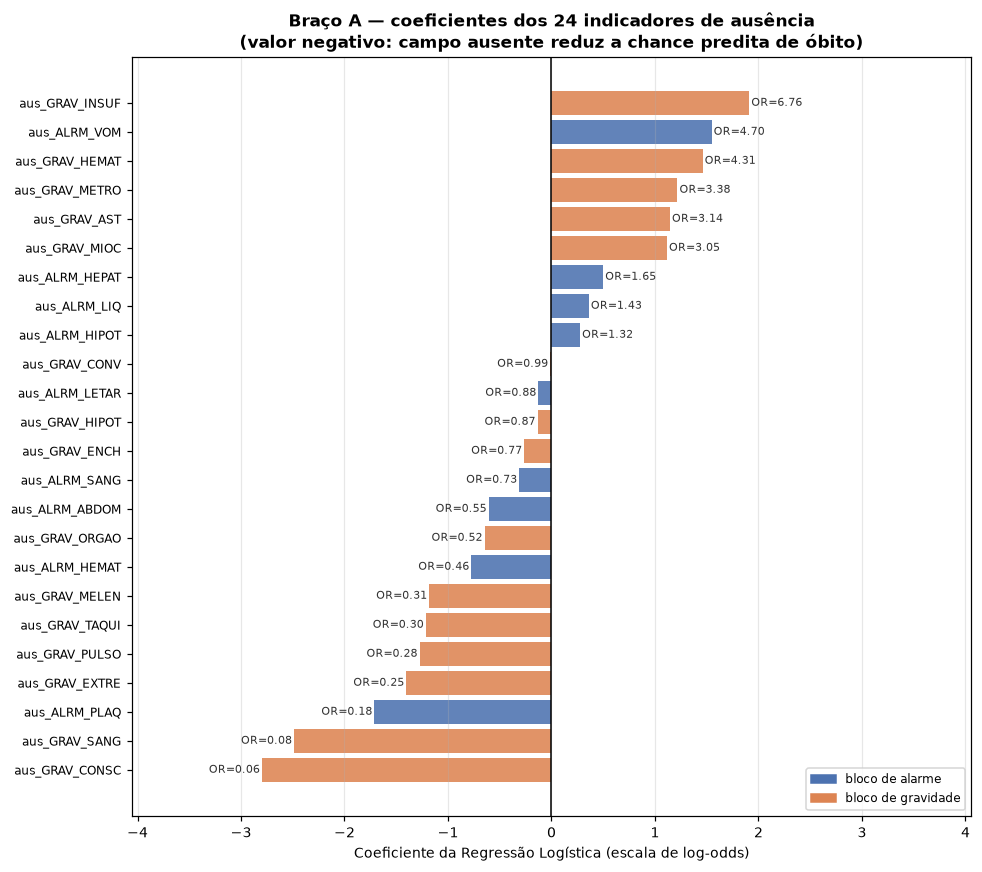

In [15]:
ordem = coefs.sort_values('coeficiente')
fig, ax = plt.subplots(figsize=(9, 8))
y = np.arange(len(ordem))
cores = [COR_LR if b == 'alarme' else COR_LGBM for b in ordem['bloco']]
ax.barh(y, ordem['coeficiente'], color=cores, alpha=0.88)
ax.set_yticks(y)
ax.set_yticklabels(ordem['indicador'], fontsize=8)
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('Coeficiente da Regressão Logística (escala de log-odds)')
ax.set_title('Braço A — coeficientes dos 24 indicadores de ausência\n'
             '(valor negativo: campo ausente reduz a chance predita de óbito)',
             fontweight='bold', fontsize=11)
ax.grid(axis='x', alpha=0.3)
for i, (_, r) in enumerate(ordem.iterrows()):
    desloc = -0.02 if r['coeficiente'] < 0 else 0.02
    ax.text(r['coeficiente'] + desloc, i, f"OR={r['razao_chances_or']:.2f}",
            va='center', ha='right' if r['coeficiente'] < 0 else 'left',
            fontsize=7, color='#333')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=COR_LR, label='bloco de alarme'),
                   Patch(color=COR_LGBM, label='bloco de gravidade')],
          fontsize=8, loc='lower right')
lim = ordem['coeficiente'].abs().max() * 1.45
ax.set_xlim(-lim, lim)
plt.tight_layout()
salvar_fig(fig, 'coeficientes_braco_a.png')
plt.show()

## 8. Estabilidade em 2025

Os braços A e D reavaliados em 2025 — ano endêmico, contra o ano epidêmico de 2024. Os modelos
continuam treinados em 2020–2023: o que muda é só o conjunto de avaliação. A regra
determinística também é recalculada. Se o padrão de preenchimento for um artefato de um ano
específico, a diferença aparece aqui.

In [16]:
estab = []
for nome in ['A. Ausência total (24)', 'D. Bloco preenchido (2)']:
    for algo in ALGOS_POR_BRACO[nome]:
        for rotulo_conj, df_aval in [('teste 2024', teste), ('validação 2025', val25)]:
            linha, _, _ = treinar_avaliar(BRACOS[nome], algo, treino, df_aval, nome)
            linha['conjunto'] = rotulo_conj
            estab.append(linha)
            print(f'{nome:26s} {algo:9s} {rotulo_conj:15s} '
                  f'AUPRC={linha["auprc"]:.4f} [{linha["auprc_ic95_inf"]:.4f}–{linha["auprc_ic95_sup"]:.4f}] '
                  f'ROC-AUC={linha["roc_auc"]:.4f} sens={linha["sensibilidade"]:.4f}')

estabilidade = pd.DataFrame(estab)
cols = (['conjunto', 'braco', 'algoritmo', 'n_teste', 'eventos_teste', 'prevalencia_teste']
        + [c for c in estabilidade.columns if c not in
           ('conjunto', 'braco', 'algoritmo', 'n_teste', 'eventos_teste', 'prevalencia_teste')])
estabilidade = estabilidade[cols]
salvar_tab(estabilidade.round(6), 'estabilidade_2024_2025.csv')
display(estabilidade[['conjunto', 'braco', 'algoritmo', 'n_teste', 'eventos_teste',
                      'prevalencia_teste', 'auprc', 'roc_auc', 'sensibilidade',
                      'especificidade', 'vpp', 'vpn']].round(4))

A. Ausência total (24)     LR        teste 2024      AUPRC=0.3424 [0.3308–0.3544] ROC-AUC=0.8348 sens=0.6413


A. Ausência total (24)     LR        validação 2025  AUPRC=0.2785 [0.2598–0.2991] ROC-AUC=0.8230 sens=0.6373


A. Ausência total (24)     LightGBM  teste 2024      AUPRC=0.3540 [0.3421–0.3668] ROC-AUC=0.8353 sens=0.6415


A. Ausência total (24)     LightGBM  validação 2025  AUPRC=0.2819 [0.2630–0.3024] ROC-AUC=0.8226 sens=0.6373


D. Bloco preenchido (2)    LR        teste 2024      AUPRC=0.3398 [0.3283–0.3520] ROC-AUC=0.8353 sens=0.6425


D. Bloco preenchido (2)    LR        validação 2025  AUPRC=0.2769 [0.2581–0.2972] ROC-AUC=0.8230 sens=0.6386


D. Bloco preenchido (2)    LightGBM  teste 2024      AUPRC=0.3498 [0.3381–0.3621] ROC-AUC=0.8357 sens=0.6425


D. Bloco preenchido (2)    LightGBM  validação 2025  AUPRC=0.2812 [0.2622–0.3011] ROC-AUC=0.8232 sens=0.6386
[tabela] analysis/results_diagnostico_ausencia/estabilidade_2024_2025.csv  (8 linhas)


,conjunto,braco,algoritmo,n_teste,eventos_teste,prevalencia_teste,auprc,roc_auc,sensibilidade,especificidade,vpp,vpn
0,teste 2024,A. Ausência total (24),LR,160302,5292,0.0330,0.3424,0.8348,0.6413,0.9776,0.4942,0.9876
1,validação 2025,A. Ausência total (24),LR,63066,1530,0.0243,0.2785,0.8230,0.6373,0.9766,0.4039,0.9908
2,teste 2024,A. Ausência total (24),LightGBM,160302,5292,0.0330,0.3540,0.8353,0.6415,0.9781,0.5001,0.9876
3,validação 2025,A. Ausência total (24),LightGBM,63066,1530,0.0243,0.2819,0.8226,0.6373,0.9769,0.4073,0.9909
4,teste 2024,D. Bloco preenchido (2),LR,160302,5292,0.0330,0.3398,0.8353,0.6425,0.9786,0.5063,0.9877
5,validação 2025,D. Bloco preenchido (2),LR,63066,1530,0.0243,0.2769,0.8230,0.6386,0.9777,0.4161,0.9909
6,teste 2024,D. Bloco preenchido (2),LightGBM,160302,5292,0.0330,0.3498,0.8357,0.6425,0.9786,0.5063,0.9877
7,validação 2025,D. Bloco preenchido (2),LightGBM,63066,1530,0.0243,0.2812,0.8232,0.6386,0.9777,0.4161,0.9909


A regra determinística recalculada em 2025, para separar a estabilidade da regra da estabilidade dos modelos.

In [17]:
regras_25 = pd.DataFrame([
    regra_deterministica(val25, 'bloco_grav_preenchido',
                         'óbito se bloco de gravidade preenchido'),
    regra_deterministica(val25, 'bloco_alrm_preenchido',
                         'óbito se bloco de alarme preenchido'),
])
regras_25['conjunto'] = 'validação 2025'
regras_ambos = pd.concat([regras, regras_25], ignore_index=True)
salvar_tab(regras_ambos, 'regra_deterministica_blocos.csv')
display(regras_ambos[['conjunto', 'regra', 'n_base', 'eventos', 'prevalencia',
                      'vp', 'fp', 'fn', 'vn', 'sensibilidade', 'especificidade',
                      'vpp', 'vpn']])

[tabela] analysis/results_diagnostico_ausencia/regra_deterministica_blocos.csv  (4 linhas)


,conjunto,regra,n_base,eventos,prevalencia,vp,fp,fn,vn,sensibilidade,especificidade,vpp,vpn
0,teste 2024,óbito se bloco de gravidade preenchido,160302,5292,0.03301,3400,3316,1892,151694,0.6425,0.9786,0.5063,0.9877
1,teste 2024,óbito se bloco de alarme preenchido,160302,5292,0.03301,3998,50954,1294,104056,0.7555,0.6713,0.0728,0.9877
2,validação 2025,óbito se bloco de gravidade preenchido,63066,1530,0.02426,977,1371,553,60165,0.6386,0.9777,0.4161,0.9909
3,validação 2025,óbito se bloco de alarme preenchido,63066,1530,0.02426,1155,21447,375,40089,0.7549,0.6515,0.0511,0.9907


Figura: AUPRC e VPP dos braços A e D em 2024 e em 2025, lado a lado, com a queda de prevalência entre os dois anos à vista.

[figura] analysis/plots/diagnostico_ausencia/estabilidade_2024_2025.png


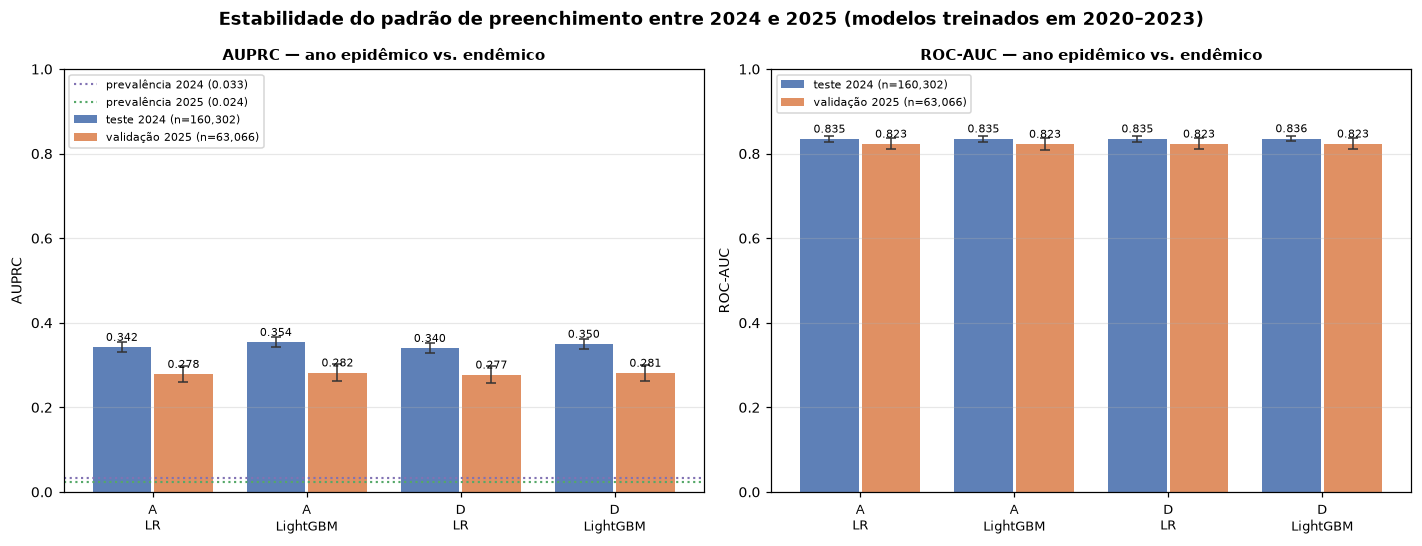

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metricas_plot = [('auprc', 'AUPRC'), ('roc_auc', 'ROC-AUC')]

for ax, (campo, titulo) in zip(axes, metricas_plot):
    rotulos = (estabilidade['braco'].str.slice(0, 2) + estabilidade['algoritmo']).unique()
    combos = estabilidade[['braco', 'algoritmo']].drop_duplicates().to_numpy()
    x = np.arange(len(combos))
    for k, (conj, cor) in enumerate([('teste 2024', COR_LR), ('validação 2025', COR_LGBM)]):
        vals, erros_inf, erros_sup, ns = [], [], [], []
        for br, al in combos:
            r = estabilidade[(estabilidade['braco'] == br) & (estabilidade['algoritmo'] == al)
                             & (estabilidade['conjunto'] == conj)].iloc[0]
            vals.append(r[campo])
            erros_inf.append(r[campo] - r[f'{campo}_ic95_inf'])
            erros_sup.append(r[f'{campo}_ic95_sup'] - r[campo])
            ns.append(int(r['n_teste']))
        ax.bar(x + (0.2 if k else -0.2), vals, width=0.38, color=cor, alpha=0.9,
               yerr=[erros_inf, erros_sup], error_kw=dict(ecolor='#333', lw=1, capsize=3),
               label=f'{conj} (n={ns[0]:,})')
        for xi, v in zip(x + (0.2 if k else -0.2), vals):
            ax.text(xi, v + 0.015, f'{v:.3f}', ha='center', fontsize=7.5)
    ax.set_xticks(x)
    ax.set_xticklabels([f'{br.split(".")[0]}\n{al}' for br, al in combos], fontsize=8.5)
    if campo == 'auprc':
        ax.axhline(PREVALENCIA, color=COR_PISO, ls=':', lw=1.4,
                   label=f'prevalência 2024 ({PREVALENCIA:.3f})')
        ax.axhline(val25['target'].mean(), color='#55A868', ls=':', lw=1.4,
                   label=f'prevalência 2025 ({val25["target"].mean():.3f})')
    ax.set_ylabel(titulo)
    ax.set_ylim(0, 1.0)
    ax.set_title(f'{titulo} — ano epidêmico vs. endêmico', fontweight='bold', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=7.5, loc='upper left')

plt.suptitle('Estabilidade do padrão de preenchimento entre 2024 e 2025 '
             '(modelos treinados em 2020–2023)', fontsize=12, fontweight='bold')
plt.tight_layout()
salvar_fig(fig, 'estabilidade_2024_2025.png')
plt.show()

## 9. Contraste com o conteúdo clínico

Restrito ao subconjunto do teste em que **o bloco de gravidade foi preenchido**
(`bloco_grav_preenchido == 1`), um modelo com os valores clínicos `GRAV_*` reais — sem nenhum
indicador de ausência. Separa "o bloco foi preenchido" de "quais sinais estavam presentes".

Duas ressalvas de leitura que vão junto com o número: neste subconjunto a prevalência de óbito
é muito mais alta que na coorte inteira, então o **piso da AUPRC sobe na mesma proporção** e a
AUPRC aqui não é comparável com a dos braços anteriores; e o treino também é restrito ao
subconjunto correspondente de 2020–2023, o que reduz bastante o N de treino.

Valores clínicos residualmente ausentes dentro do bloco preenchido são imputados com 0, como
faz o `ColumnTransformer` dos notebooks de modelo — mantendo a comparabilidade com o publicado.

In [19]:
treino_sub = treino[treino['bloco_grav_preenchido'] == 1]
teste_sub  = teste[teste['bloco_grav_preenchido'] == 1]

print(f'Treino (2020–2023) com bloco de gravidade preenchido: {len(treino_sub):,} de {len(treino):,} '
      f'({len(treino_sub) / len(treino) * 100:.2f}%) | {int(treino_sub["target"].sum()):,} óbitos '
      f'({treino_sub["target"].mean() * 100:.2f}%)')
print(f'Teste  (2024)      com bloco de gravidade preenchido: {len(teste_sub):,} de {len(teste):,} '
      f'({len(teste_sub) / len(teste) * 100:.2f}%) | {int(teste_sub["target"].sum()):,} óbitos '
      f'({teste_sub["target"].mean() * 100:.2f}%)')

n_resid = int(teste_sub[GRAV_COLS].isna().sum().sum())
print(f'\nValores clínicos GRAV_* ainda ausentes dentro do bloco preenchido (teste): '
      f'{n_resid:,} de {len(teste_sub) * len(GRAV_COLS):,} células '
      f'({n_resid / (len(teste_sub) * len(GRAV_COLS)) * 100:.2f}%) — imputados com 0.')

clinico = []
for algo in ['LR', 'LightGBM']:
    linha, _, proba_c = treinar_avaliar(GRAV_COLS, algo, treino_sub, teste_sub,
                                        'F. Clínico GRAV_* | bloco preenchido')
    linha['piso_auprc_prevalencia_subconjunto'] = round(float(teste_sub['target'].mean()), 5)
    clinico.append(linha)
    print(f'  {algo:9s} AUPRC={linha["auprc"]:.4f} '
          f'[{linha["auprc_ic95_inf"]:.4f}–{linha["auprc_ic95_sup"]:.4f}]  '
          f'ROC-AUC={linha["roc_auc"]:.4f}  sens={linha["sensibilidade"]:.4f}')

# comparacao no MESMO subconjunto: so a ausencia dos ALRM_* (a dos GRAV_* e constante aqui)
for algo in ['LR', 'LightGBM']:
    linha, _, _ = treinar_avaliar(AUS_ALRM_COLS, algo, treino_sub, teste_sub,
                                  'G. Ausência ALRM | bloco GRAV preenchido')
    linha['piso_auprc_prevalencia_subconjunto'] = round(float(teste_sub['target'].mean()), 5)
    clinico.append(linha)
    print(f'  [contraste] ausência ALRM {algo:9s} AUPRC={linha["auprc"]:.4f}  '
          f'ROC-AUC={linha["roc_auc"]:.4f}')

contraste = pd.DataFrame(clinico)
salvar_tab(contraste.round(6), 'contraste_clinico_grav.csv')
display(contraste[['braco', 'algoritmo', 'n_preditores', 'n_treino', 'eventos_treino',
                   'n_teste', 'eventos_teste', 'prevalencia_teste',
                   'piso_auprc_prevalencia_subconjunto', 'auprc', 'roc_auc',
                   'sensibilidade', 'especificidade', 'vpp', 'vpn']].round(4))

print(f'\nPiso da AUPRC neste subconjunto: {teste_sub["target"].mean():.4f} '
      f'(contra {PREVALENCIA:.4f} no teste completo). O ganho sobre o piso é a leitura útil.')
for _, r in contraste.iterrows():
    print(f'  {r["braco"]:42s} {r["algoritmo"]:9s} AUPRC={r["auprc"]:.4f}  '
          f'ganho sobre o piso = {r["auprc"] - r["piso_auprc_prevalencia_subconjunto"]:+.4f}  '
          f'ROC-AUC={r["roc_auc"]:.4f}')

Treino (2020–2023) com bloco de gravidade preenchido: 3,533 de 127,074 (2.78%) | 1,799 óbitos (50.92%)
Teste  (2024)      com bloco de gravidade preenchido: 6,716 de 160,302 (4.19%) | 3,400 óbitos (50.63%)

Valores clínicos GRAV_* ainda ausentes dentro do bloco preenchido (teste): 1,451 de 100,740 células (1.44%) — imputados com 0.


  LR        AUPRC=0.8510 [0.8375–0.8640]  ROC-AUC=0.8612  sens=0.6738


  LightGBM  AUPRC=0.8463 [0.8328–0.8583]  ROC-AUC=0.8558  sens=0.7115


  [contraste] ausência ALRM LR        AUPRC=0.5180  ROC-AUC=0.5171


  [contraste] ausência ALRM LightGBM  AUPRC=0.5145  ROC-AUC=0.5158
[tabela] analysis/results_diagnostico_ausencia/contraste_clinico_grav.csv  (4 linhas)


,braco,algoritmo,n_preditores,n_treino,eventos_treino,n_teste,eventos_teste,prevalencia_teste,piso_auprc_prevalencia_subconjunto,auprc,roc_auc,sensibilidade,especificidade,vpp,vpn
0,F. Clínico GRAV_* | bloco preenchido,LR,15,3533,1799,6716,3400,0.5062,0.5062,0.8510,0.8612,0.6738,0.8791,0.8510,0.7244
1,F. Clínico GRAV_* | bloco preenchido,LightGBM,15,3533,1799,6716,3400,0.5062,0.5062,0.8463,0.8558,0.7115,0.8456,0.8253,0.7408
2,G. Ausência ALRM | bloco GRAV preenchido,LR,9,3533,1799,6716,3400,0.5062,0.5062,0.5180,0.5171,0.1029,0.9312,0.6055,0.5031
3,G. Ausência ALRM | bloco GRAV preenchido,LightGBM,9,3533,1799,6716,3400,0.5062,0.5062,0.5145,0.5158,0.1003,0.9343,0.6100,0.5032



Piso da AUPRC neste subconjunto: 0.5063 (contra 0.0330 no teste completo). O ganho sobre o piso é a leitura útil.
  F. Clínico GRAV_* | bloco preenchido       LR        AUPRC=0.8510  ganho sobre o piso = +0.3447  ROC-AUC=0.8612
  F. Clínico GRAV_* | bloco preenchido       LightGBM  AUPRC=0.8463  ganho sobre o piso = +0.3400  ROC-AUC=0.8558
  G. Ausência ALRM | bloco GRAV preenchido   LR        AUPRC=0.5180  ganho sobre o piso = +0.0117  ROC-AUC=0.5171
  G. Ausência ALRM | bloco GRAV preenchido   LightGBM  AUPRC=0.5145  ganho sobre o piso = +0.0083  ROC-AUC=0.5158


## Conclusões

- O padrão de preenchimento sozinho reproduz mais da metade da AUPRC publicada.
  O braço A, com os 24 indicadores de ausência e nenhum valor clínico, alcança AUPRC de 0,3424 [0,3308; 0,3544] na Logistic Regression e 0,3540 [0,3421; 0,3668] no LightGBM, contra 0,625 e 0,629 publicados: 54,8% e 56,3% da AUPRC de referência.

- O piso de prevalência do teste de 2024 é 0,0330, de modo que a AUPRC dos braços de ausência está cerca de dez vezes acima do que um classificador aleatório alcançaria.

- Dois indicadores bastam. O braço D, só com `bloco_alarme_avaliado` e `bloco_gravidade_avaliado`, alcança AUPRC de 0,3398 na Logistic Regression e 0,3498 no LightGBM, praticamente o mesmo que os 24 indicadores do braço A.
  Com um único indicador, o braço E chega a 0,3371.

- Quase toda a informação está no bloco de gravidade.
  O braço C, com os 15 indicadores de gravidade, alcança 0,3403 e 0,3398, enquanto o braço B, com os 9 de alarme, fica em 0,0635 e 0,0671, perto do piso.

- Sem nenhum modelo, a regra "óbito se o bloco de gravidade estiver preenchido" alcança sensibilidade de 0,6425 [0,6299; 0,6553], especificidade de 0,9786 e VPP de 0,5063 [0,4941; 0,5190] no teste de 2024, com 3.400 verdadeiros positivos, 3.316 falsos positivos e 1.892 falsos negativos.
  A regra equivalente para o bloco de alarme alcança sensibilidade 0,7555, mas VPP de apenas 0,0728.

- A ausência depende fortemente do desfecho, que é o que torna o padrão preditivo.
  Nos 15 critérios de gravidade a ausência é de cerca de 98,1% nas curas contra cerca de 35,0% nos óbitos; nos 9 sinais de alarme, cerca de 70,5% contra cerca de 25,2%.
  A razão entre as duas fica em torno de 0,36 nos 24 campos.

- O padrão não é artefato de um único ano.
  Em 2025 os braços A e D mantêm ROC-AUC de 0,8226 a 0,8232 e sensibilidade de 0,6373 a 0,6386, contra 0,8348 a 0,8357 e 0,6413 a 0,6425 em 2024.
  A AUPRC cai de 0,3424 para 0,2785 no braço A da Logistic Regression, acompanhando a queda da prevalência, de 3,3% para 2,4%.

- O conteúdo clínico continua informativo onde existe, mas sobre um piso muito mais alto.
  No subconjunto em que o bloco de gravidade foi preenchido, a prevalência de óbito é de 50,6% e os valores clínicos `GRAV_*` alcançam AUPRC de 0,8510 na Logistic Regression e 0,8463 no LightGBM, o que representa ganho de 0,3447 e 0,3400 sobre o piso de 0,5063.
  Nesse mesmo subconjunto, os indicadores de ausência do bloco de alarme ganham apenas 0,0117 e 0,0083 sobre o piso.

- Os coeficientes do braço A não têm leitura clínica coerente: os dois maiores em valor absoluto são negativos, `aus_GRAV_CONSC` com -2,7973 e razão de chances 0,0610 e `aus_GRAV_SANG` com -2,4869, e o terceiro, `aus_GRAV_INSUF`, é positivo com +1,9110 e razão de chances 6,7596, embora os 15 campos tenham praticamente a mesma taxa de ausência.
  O que o modelo aprende é a combinação de disponibilidade dos campos, não o significado clínico de cada um.

- A implementação de `ap_auc` confere com o scikit-learn na ordem de 1e-9, diferença de acúmulo em ponto flutuante e não de definição.